In [115]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, average_precision_score, precision_recall_curve
from sklearn.preprocessing import LabelEncoder, OneHotEncoder #i may end up using only one of them
from sklearn.preprocessing import StandardScaler, RobustScaler # same here
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
!pip install catboost
from catboost import CatBoostClassifier
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score

In [116]:
# !unzip /content/adult-dataset.zip

In [117]:
Train = pd.read_csv('train1.csv')
Test = pd.read_csv('test.csv')
Sub = pd.read_csv('sample_submission.csv')

In [118]:
Train.shape

(39073, 16)

In [119]:
Test.shape

(9769, 15)

In [120]:
Train

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income,id
0,32,Private,50753,HS-grad,9,Married-civ-spouse,Transport-moving,Husband,White,Male,0,0,40,United-States,<=50K,37194
1,45,State-gov,144351,Masters,14,Married-civ-spouse,Prof-specialty,Husband,White,Male,0,0,40,United-States,>50K,31094
2,35,Local-gov,252217,12th,8,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,40,United-States,<=50K,33815
3,64,Private,69525,HS-grad,9,Divorced,Craft-repair,Unmarried,White,Male,0,0,20,United-States,<=50K,14501
4,63,Self-emp-not-inc,28612,HS-grad,9,Widowed,Sales,Not-in-family,White,Male,0,0,70,United-States,<=50K,23400
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39068,35,Private,200117,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,Asian-Pac-Islander,Male,0,1887,50,?,>50K,11285
39069,21,Private,90896,HS-grad,9,Never-married,Machine-op-inspct,Own-child,White,Female,0,0,40,United-States,<=50K,44733
39070,23,Private,370057,HS-grad,9,Divorced,Adm-clerical,Not-in-family,White,Female,0,0,40,United-States,<=50K,38159
39071,18,Private,216284,11th,7,Never-married,Adm-clerical,Own-child,White,Female,0,0,20,United-States,<=50K,861


In [121]:
Train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39073 entries, 0 to 39072
Data columns (total 16 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             39073 non-null  int64 
 1   workclass       38301 non-null  object
 2   fnlwgt          39073 non-null  int64 
 3   education       39073 non-null  object
 4   education-num   39073 non-null  int64 
 5   marital-status  39073 non-null  object
 6   occupation      38299 non-null  object
 7   relationship    39073 non-null  object
 8   race            39073 non-null  object
 9   sex             39073 non-null  object
 10  capital-gain    39073 non-null  int64 
 11  capital-loss    39073 non-null  int64 
 12  hours-per-week  39073 non-null  int64 
 13  native-country  38861 non-null  object
 14  income          39073 non-null  object
 15  id              39073 non-null  int64 
dtypes: int64(7), object(9)
memory usage: 4.8+ MB


In [122]:
Train.isna().sum()

,0
age,0
workclass,772
fnlwgt,0
education,0
education-num,0
marital-status,0
occupation,774
relationship,0
race,0
sex,0


In [123]:
Train.drop("id", axis=1, inplace=True)

In [124]:
numerical = Train.select_dtypes(include=np.number).columns
print(numerical)
print(numerical.shape)
print("\n")
categorical = Train.select_dtypes(include='object').columns
print(categorical)
print(numerical.shape)

Index(['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss',
       'hours-per-week'],
      dtype='object')
(6,)


Index(['workclass', 'education', 'marital-status', 'occupation',
       'relationship', 'race', 'sex', 'native-country', 'income'],
      dtype='object')
(6,)


In [125]:
Train.shape

(39073, 15)

In [126]:
#filling workclass, occupation and native-country
for data in [Train, Test]:
  data['workclass'] = data['workclass'].fillna('Unknown')
  data['occupation'] = data['occupation'].fillna('Unknown')
  data['native-country'] = data['native-country'].fillna(Train['native-country'].mode()[0])

In [127]:
Train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39073 entries, 0 to 39072
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             39073 non-null  int64 
 1   workclass       39073 non-null  object
 2   fnlwgt          39073 non-null  int64 
 3   education       39073 non-null  object
 4   education-num   39073 non-null  int64 
 5   marital-status  39073 non-null  object
 6   occupation      39073 non-null  object
 7   relationship    39073 non-null  object
 8   race            39073 non-null  object
 9   sex             39073 non-null  object
 10  capital-gain    39073 non-null  int64 
 11  capital-loss    39073 non-null  int64 
 12  hours-per-week  39073 non-null  int64 
 13  native-country  39073 non-null  object
 14  income          39073 non-null  object
dtypes: int64(6), object(9)
memory usage: 4.5+ MB


In [128]:
Train.shape

(39073, 15)

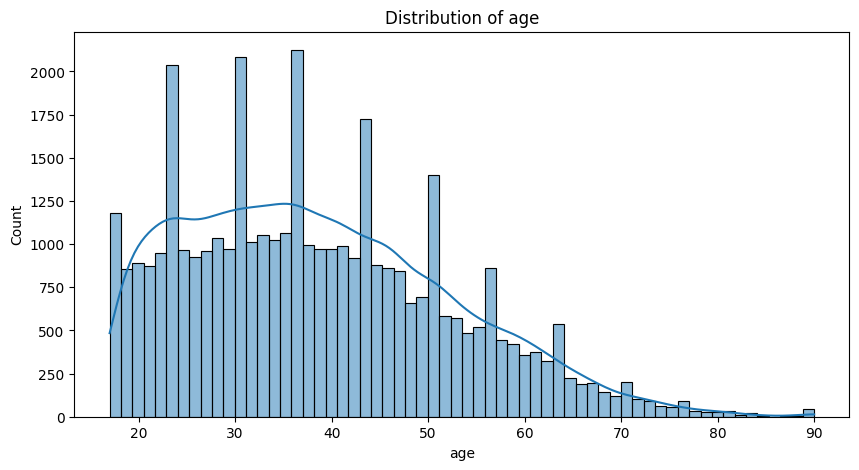

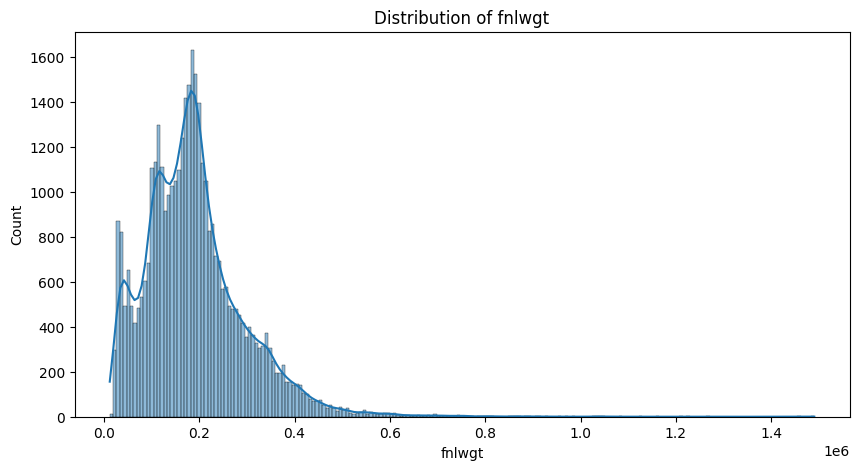

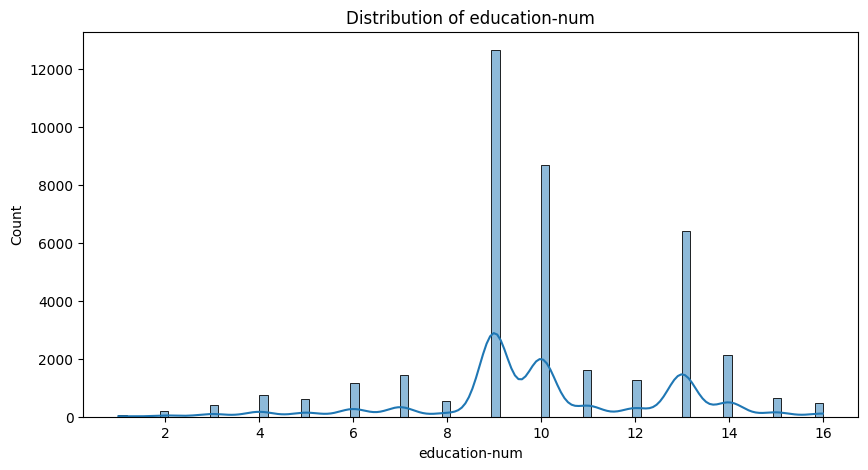

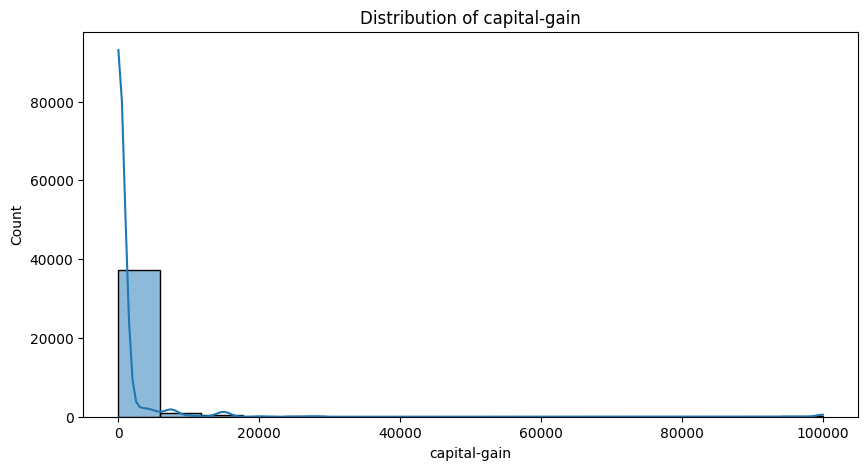

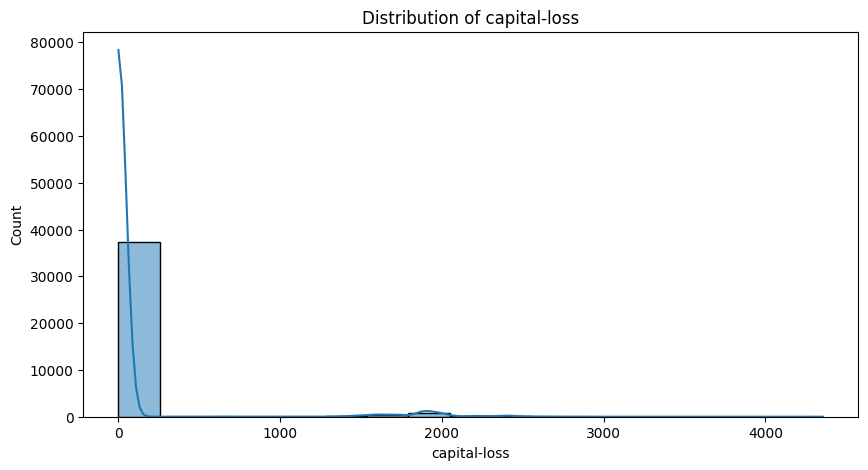

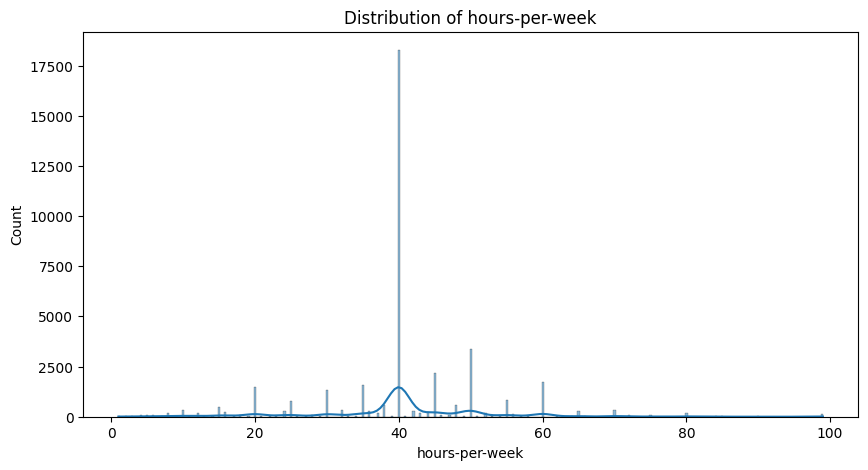

In [129]:
for col in numerical:
  plt.figure(figsize=(10, 5))
  sns.histplot(Train[col], kde=True)
  plt.title(f"Distribution of {col}")

In [130]:
for col in numerical:
  skewness = Train[col].skew()
  kurtosis = Train[col].kurtosis()
  outlier = Train[col].quantile(0.75)
  print(f"Skewness of {col}: {skewness}")
  print(f"Kurtosis of {col}: {kurtosis}")
  print("\n")

Skewness of age: 0.5584762774967195
Kurtosis of age: -0.19045441444862332


Skewness of fnlwgt: 1.4487557725108493
Kurtosis of fnlwgt: 6.080596994878366


Skewness of education-num: -0.3063860463617506
Kurtosis of education-num: 0.6089658378241389


Skewness of capital-gain: 11.827158640205797
Kurtosis of capital-gain: 150.83714418997306


Skewness of capital-loss: 4.585886388106252
Kurtosis of capital-loss: 20.22078122943555


Skewness of hours-per-week: 0.23848111093274002
Kurtosis of hours-per-week: 2.977127807929232




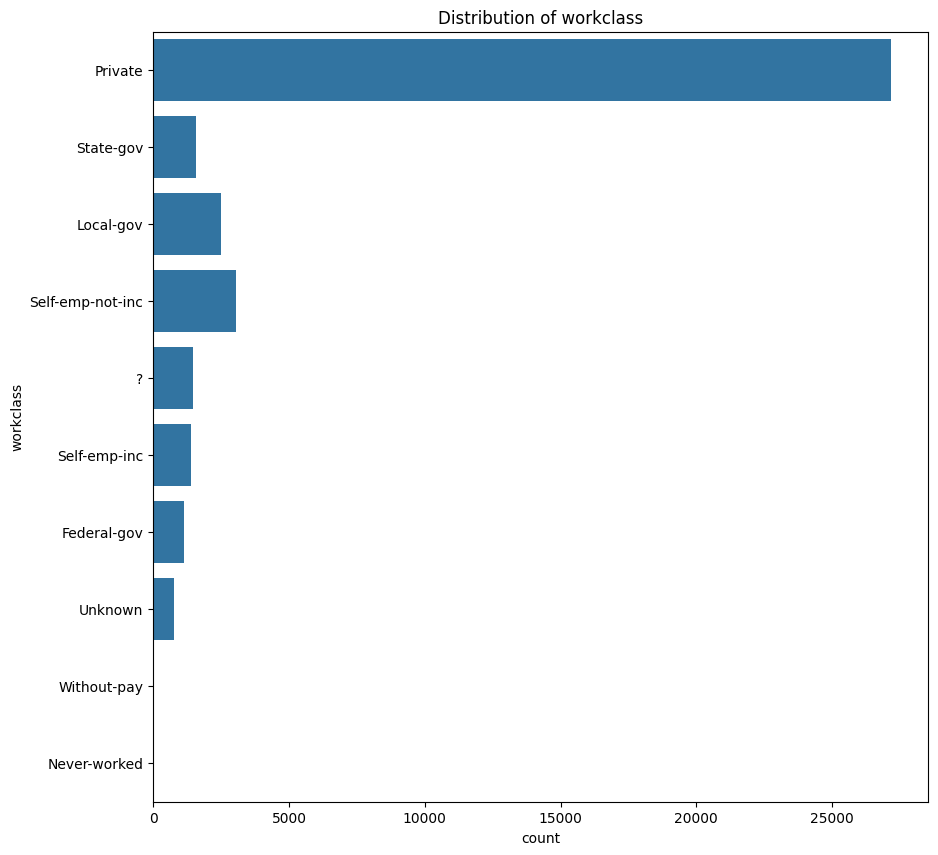

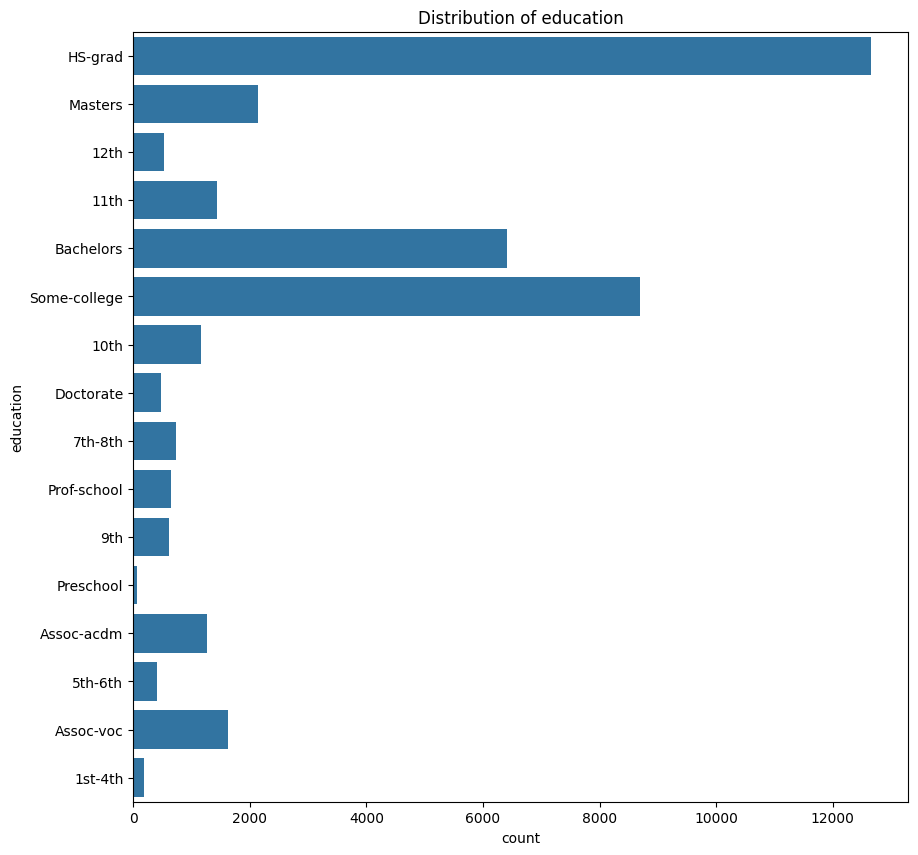

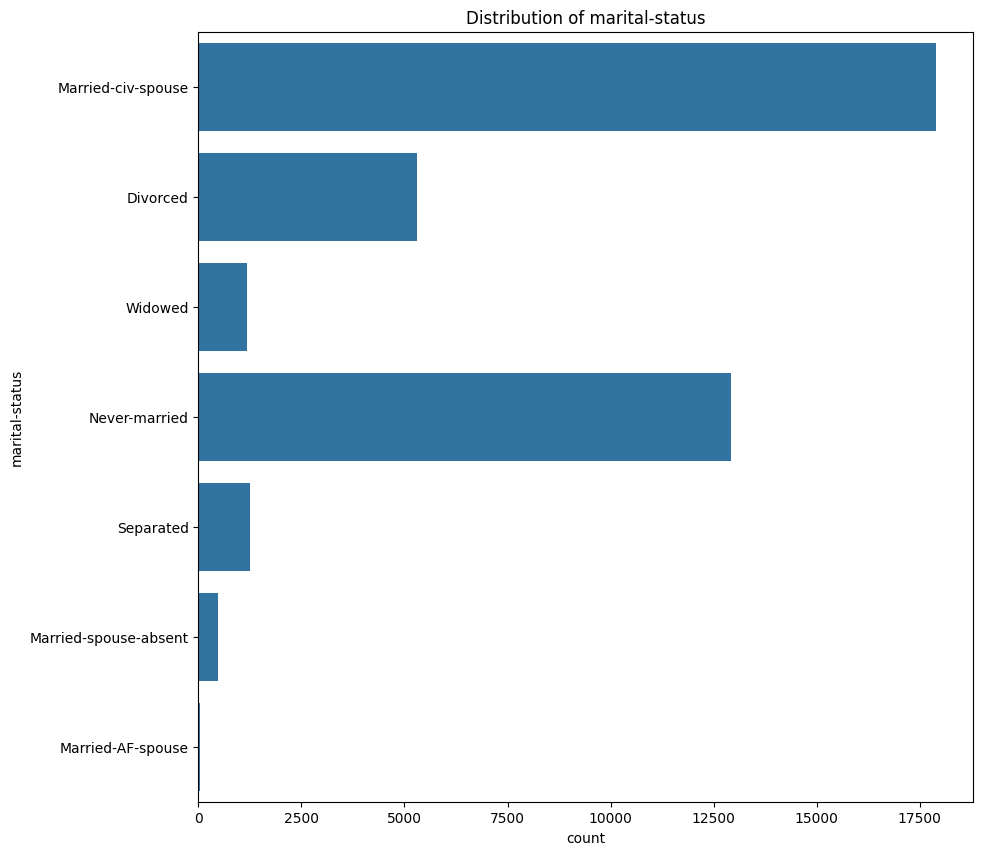

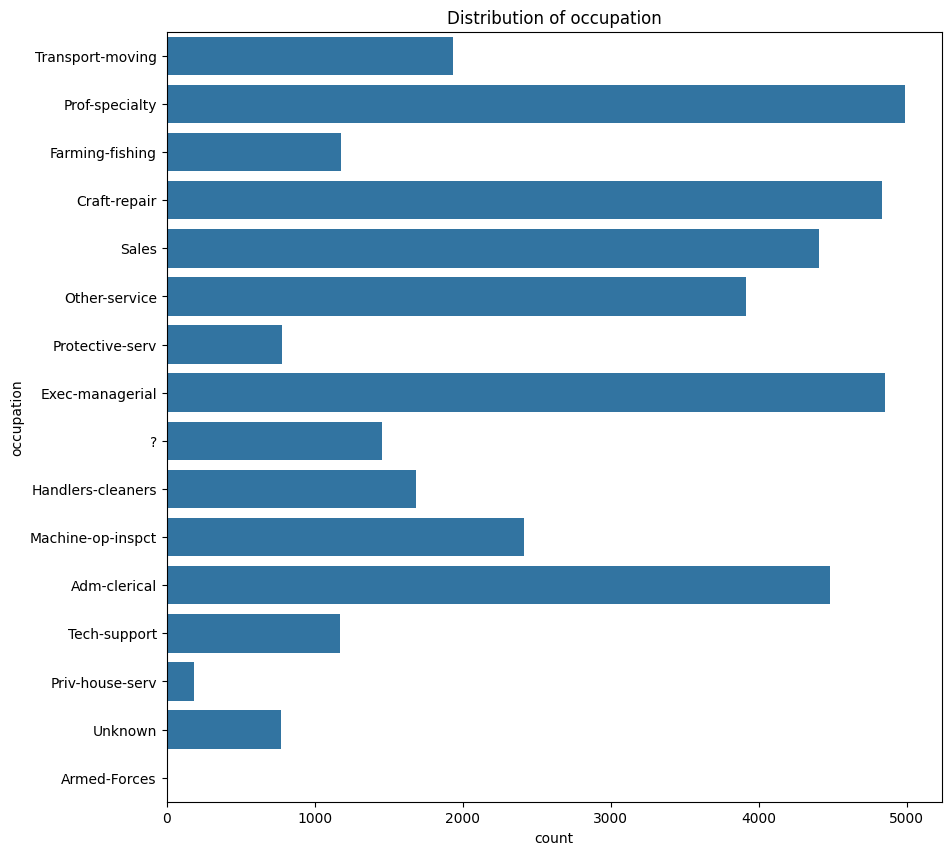

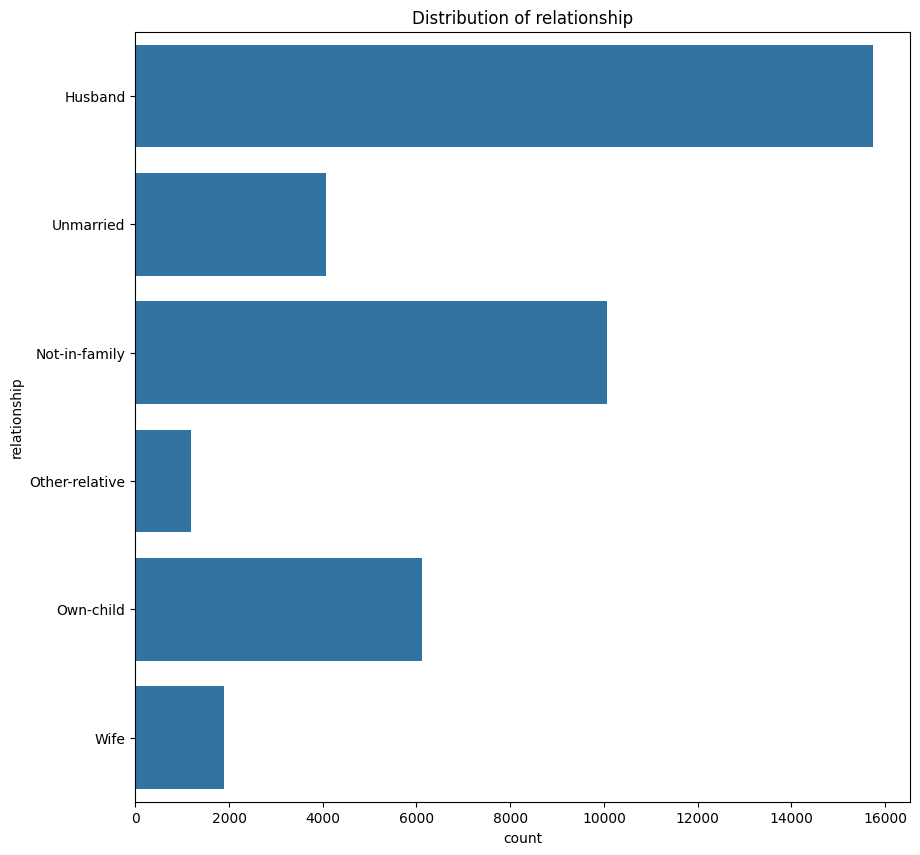

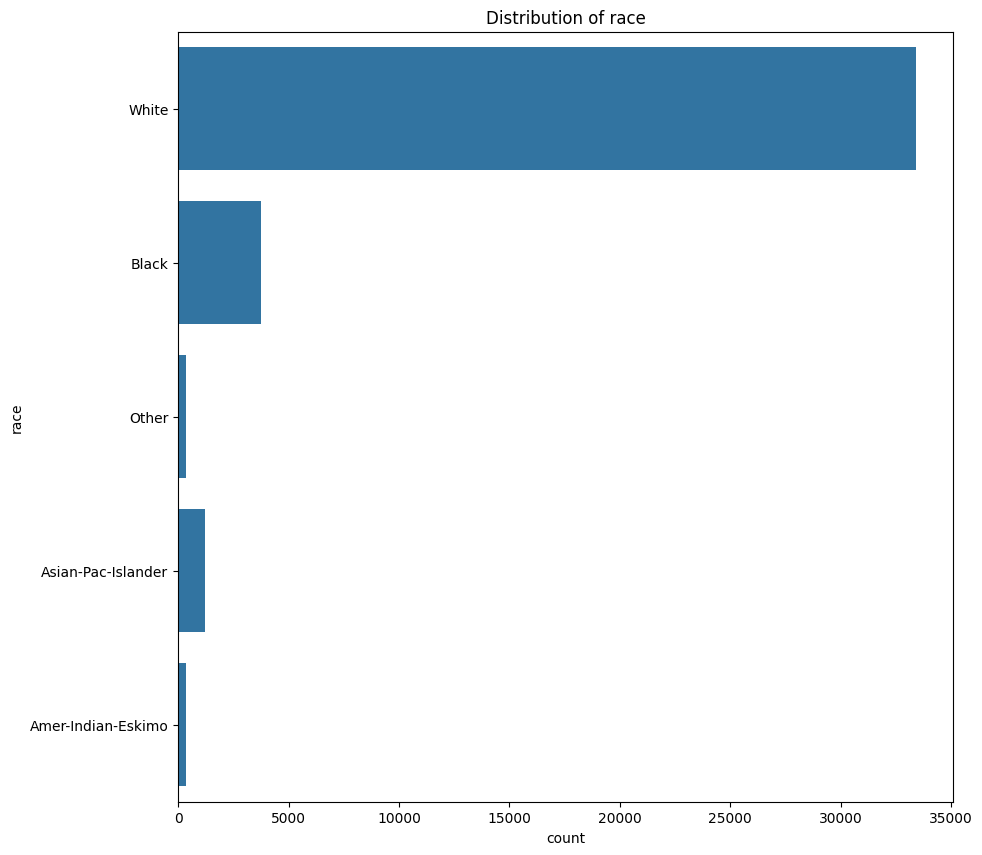

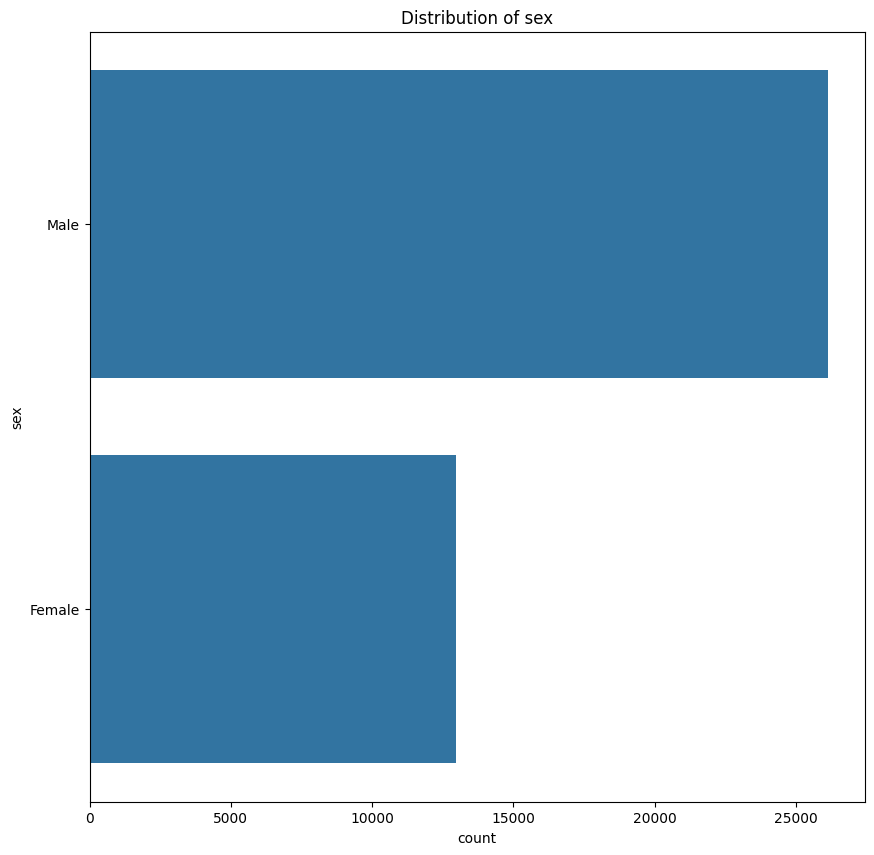

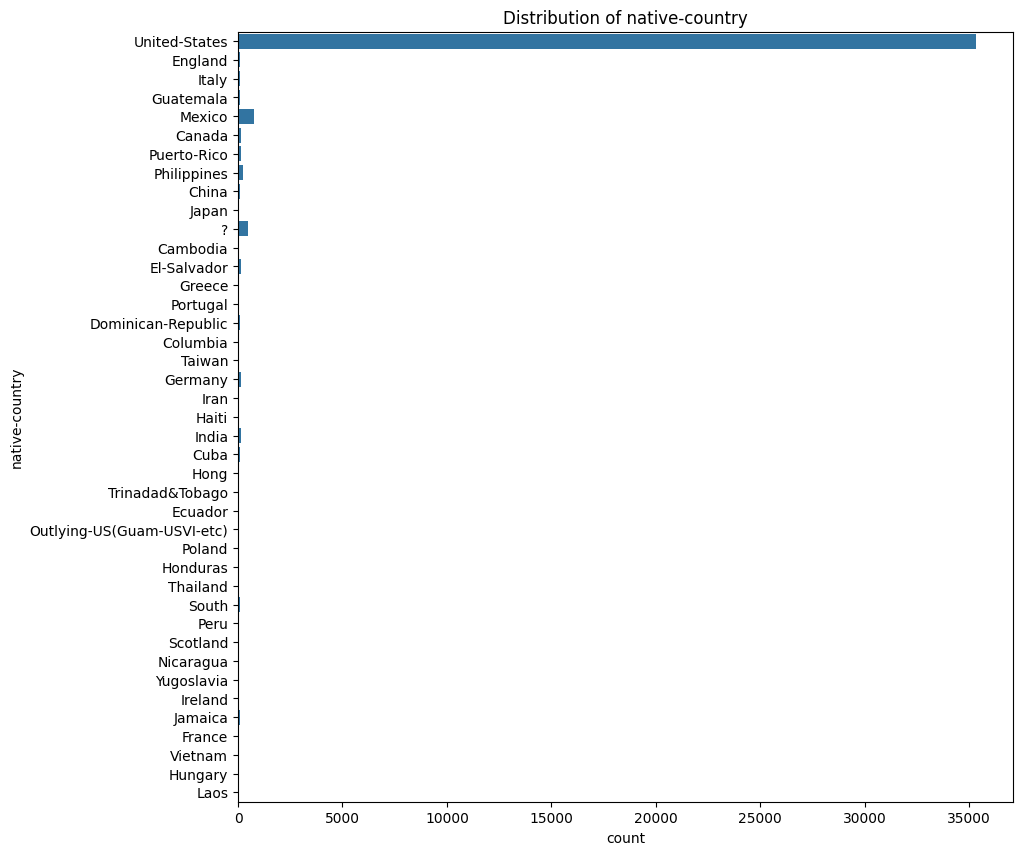

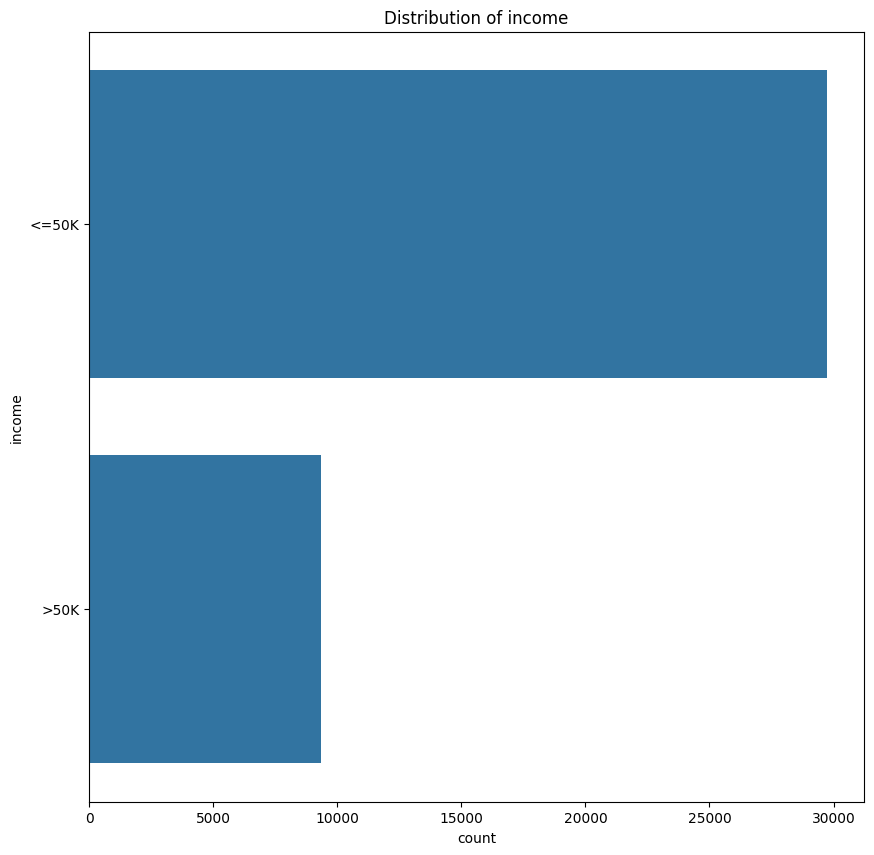

In [131]:
for col in categorical:
  plt.figure(figsize=(10, 10))
  sns.countplot(Train[col])
  plt.title(f"Distribution of {col}")

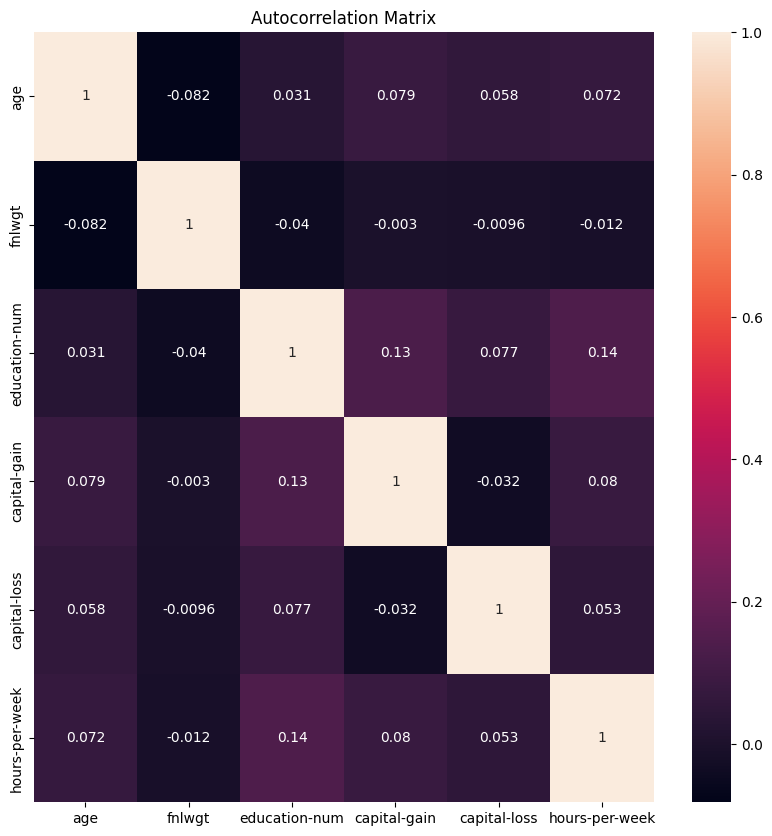

In [132]:
from matplotlib import colormaps
corr_matrix = Train.corr(numeric_only=True)
plt.figure(figsize=(10, 10))
sns.heatmap(corr_matrix, annot=True)
plt.title("Autocorrelation Matrix")
plt.show()
#we got no autocorr problem here

In [133]:
#high imbalance in native country and education
#Grouping the data of countries and education (claude made):
country_to_region = {
    # North America
    'United-States': 'North-America',
    'Canada': 'North-America',
    'Puerto-Rico': 'North-America',
    'Outlying-US(Guam-USVI-etc)': 'North-America',

    # Latin America
    'Mexico': 'Latin-America',
    'Guatemala': 'Latin-America',
    'El-Salvador': 'Latin-America',
    'Dominican-Republic': 'Latin-America',
    'Columbia': 'Latin-America',
    'Ecuador': 'Latin-America',
    'Honduras': 'Latin-America',
    'Peru': 'Latin-America',
    'Nicaragua': 'Latin-America',
    'Cuba': 'Latin-America',
    'Jamaica': 'Latin-America',
    'Haiti': 'Latin-America',
    'Trinadad&Tobago': 'Latin-America',

    # Europe
    'England': 'Europe',
    'Italy': 'Europe',
    'Greece': 'Europe',
    'Portugal': 'Europe',
    'Germany': 'Europe',
    'Poland': 'Europe',
    'Yugoslavia': 'Europe',
    'Ireland': 'Europe',
    'France': 'Europe',
    'Hungary': 'Europe',
    'Scotland': 'Europe',

    # Asia
    'Philippines': 'Asia',
    'China': 'Asia',
    'Japan': 'Asia',
    'Cambodia': 'Asia',
    'India': 'Asia',
    'Hong': 'Asia',# Hong Kong
    'Taiwan': 'Asia',
    'Thailand': 'Asia',
    'Vietnam': 'Asia',
    'Laos': 'Asia',
    'South': 'Asia',# South Korea

    # Middle East
    'Iran': 'Middle-East',

    '?': 'Unknown'
}


edu_to_level = {
    'Preschool': 'Low',
    '1st-4th': 'Low',
    '5th-6th': 'Low',
    '7th-8th': 'Low',
    '9th': 'Low',
    '10th': 'Low',
    '11th': 'Low',
    '12th': 'Low',
    'HS-grad': 'High-School',
    'Some-college': 'Some-College',
    'Assoc-voc': 'Associate',
    'Assoc-acdm': 'Associate',
    'Bachelors': 'Bachelors',
    'Masters': 'Graduate',
    'Prof-school': 'Graduate',
    'Doctorate': 'Graduate'
}

#FE
for data in [Train, Test]:
    data['country_region']  = data['native-country'].map(country_to_region).fillna('Other')
    data['education_level'] = data['education'].map(edu_to_level)
    data["young_age"] = (data["age"] < 25).astype(int)
    data['YoungOld_age'] = data['age'].between(25,50).astype(int)
    data['exp_age'] = data['age'].between(35,55).astype(int)
    data['retirement_age'] = (data['age'] > 65).astype(int)
    # data['exp_age'] = data['age'].between(35,55).astype(int)
    # data['Extra_Hours_Work'] = (data['hours-per-week'] > 45).astype(int)
    # data['Married_Educ'] = data['marital-status'] * data['education-num']
    # data['age_education'] = data['age'] * data['education-num']
    # data['fnlwgt'] = np.log1p(data['fnlwgt'])
    # data['log_age'] = np.log1p(data['age'])
    # data['CapLoss_CapGain'] = data['capital-loss'] * data['capital-gain']

In [134]:
Train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39073 entries, 0 to 39072
Data columns (total 21 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   age              39073 non-null  int64 
 1   workclass        39073 non-null  object
 2   fnlwgt           39073 non-null  int64 
 3   education        39073 non-null  object
 4   education-num    39073 non-null  int64 
 5   marital-status   39073 non-null  object
 6   occupation       39073 non-null  object
 7   relationship     39073 non-null  object
 8   race             39073 non-null  object
 9   sex              39073 non-null  object
 10  capital-gain     39073 non-null  int64 
 11  capital-loss     39073 non-null  int64 
 12  hours-per-week   39073 non-null  int64 
 13  native-country   39073 non-null  object
 14  income           39073 non-null  object
 15  country_region   39073 non-null  object
 16  education_level  39073 non-null  object
 17  young_age        39073 non-null

In [135]:
feature_drop = ["native-country", "education"]
Train.drop(feature_drop, axis=1, inplace=True)
Test.drop(feature_drop, axis=1, inplace=True)

In [136]:
Train.shape

(39073, 19)

In [137]:
Train.columns

Index(['age', 'workclass', 'fnlwgt', 'education-num', 'marital-status',
       'occupation', 'relationship', 'race', 'sex', 'capital-gain',
       'capital-loss', 'hours-per-week', 'income', 'country_region',
       'education_level', 'young_age', 'YoungOld_age', 'exp_age',
       'retirement_age'],
      dtype='object')

In [138]:
Y_train = Train['income']
Train = Train.drop('income', axis=1)
#processing cat data
Train = pd.get_dummies(Train, dtype=int)
Test = pd.get_dummies(Test, dtype=int)
Train, Test = Train.align(Test, join='left', axis=1, fill_value=0)

In [139]:
#scalling num data
sc = StandardScaler()
Train[numerical] = sc.fit_transform(Train[numerical])
Test[numerical] = sc.transform(Test[numerical])

In [140]:
Train = pd.DataFrame(Train)
Test = pd.DataFrame(Test)
X_train = Train

In [141]:
X_train, X_val, Y_train, Y_val = train_test_split(
    Train, Y_train,
    test_size=0.2, random_state=42, stratify=Y_train
)

In [142]:
Decision_tree = DecisionTreeClassifier(
    max_depth=5,
    min_samples_split=20,
    min_samples_leaf=10,
    max_features=5,
    random_state = 42
)
Decision_tree.fit(X_train, Y_train)

DecisionTreeClassifier(max_depth=15, max_features=5, min_samples_leaf=10,
                       min_samples_split=20, random_state=42)

In [143]:
Y_pred_repport = Decision_tree.predict(X_val)
print(classification_report(Y_val, Y_pred_repport))

              precision    recall  f1-score   support

       <=50K       0.85      0.96      0.90      5949
        >50K       0.78      0.47      0.59      1866

    accuracy                           0.84      7815
   macro avg       0.82      0.72      0.75      7815
weighted avg       0.84      0.84      0.83      7815



In [144]:
Y_pred = Decision_tree.predict(Test)

In [145]:
Sub['income'] = Y_pred
Sub.to_csv('RandomTree6.csv', index=False)

In [146]:
RFC = RandomForestClassifier(
    n_estimators=250,
    max_depth=15,
    min_samples_split=20,
    min_samples_leaf=15,
    max_features=5,
    random_state = 42
)
RFC.fit(X_train, Y_train)

RandomForestClassifier(max_depth=15, max_features=5, min_samples_leaf=15,
                       min_samples_split=20, n_estimators=250, random_state=42)

In [147]:
Y_pred_repport = RFC.predict(X_val)
print(classification_report(Y_val, Y_pred_repport))

              precision    recall  f1-score   support

       <=50K       0.87      0.95      0.91      5949
        >50K       0.79      0.56      0.65      1866

    accuracy                           0.86      7815
   macro avg       0.83      0.76      0.78      7815
weighted avg       0.85      0.86      0.85      7815



In [148]:
Y_proba     = RFC.predict_proba(X_val)[:, 1]  # probability of >50K
pr_auc      = average_precision_score(Y_val, Y_proba, pos_label='>50K')
print(pr_auc)

0.7876394067353912


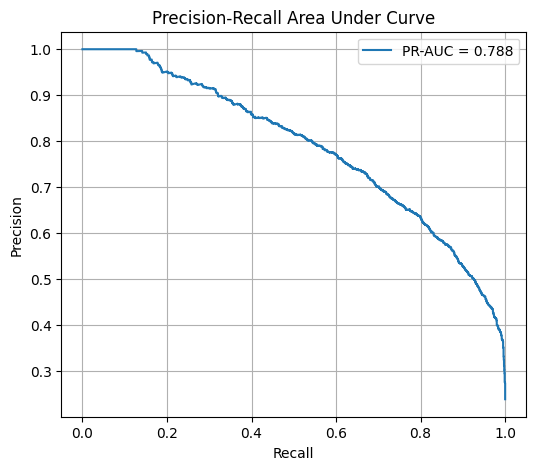

In [149]:
precision, recall, _ = precision_recall_curve(Y_val, Y_proba, pos_label='>50K')

# Plot
plt.figure(figsize=(6, 5))
plt.plot(recall, precision, label=f'PR-AUC = {pr_auc:.3f}')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Area Under Curve')
plt.legend()
plt.grid(True)
plt.show()

In [150]:
Y_pred = RFC.predict(Test)

In [151]:
Sub['income'] = Y_pred
Sub.to_csv("RFC14.csv", index=False)

In [152]:
#catboot
cb = CatBoostClassifier(
    iterations=1000,
    learning_rate=0.05,
    depth=6,
    loss_function='Logloss',
    random_seed=42,
    verbose=100 # Shows progress every 100 round
)
cb.fit(X_train, Y_train)

0:	learn: 0.6398752	total: 98.1ms	remaining: 1m 37s
100:	learn: 0.2896476	total: 2.64s	remaining: 23.5s
200:	learn: 0.2738824	total: 4.96s	remaining: 19.7s
300:	learn: 0.2624689	total: 7.22s	remaining: 16.8s
400:	learn: 0.2546455	total: 10.2s	remaining: 15.2s
500:	learn: 0.2481817	total: 13.9s	remaining: 13.8s
600:	learn: 0.2424067	total: 16.4s	remaining: 10.9s
700:	learn: 0.2374623	total: 18.9s	remaining: 8.08s
800:	learn: 0.2328083	total: 20.2s	remaining: 5.02s
900:	learn: 0.2284276	total: 21.2s	remaining: 2.33s
999:	learn: 0.2245964	total: 22.2s	remaining: 0us


CatBoostClassifier(depth=6, iterations=1000, learning_rate=0.05, loss_function='Logloss', random_seed=42, verbose=100)

In [154]:
Y_pred = cb.predict(X_val)
print(classification_report(Y_val, Y_pred))

              precision    recall  f1-score   support

       <=50K       0.90      0.94      0.92      5949
        >50K       0.79      0.65      0.71      1866

    accuracy                           0.87      7815
   macro avg       0.84      0.80      0.82      7815
weighted avg       0.87      0.87      0.87      7815



In [153]:
y_pred = cb.predict(Test)
Sub['income'] = y_pred
Sub.to_csv("RFC15.csv", index=False)

In [175]:
#ensembeling
from sklearn.ensemble import VotingClassifier
ensemble = VotingClassifier(
    estimators=[
        ('cat', cb),
        ('rfc', RFC),
    ],
    voting='soft',
    weights=[2, 1]
)

ensemble.fit(X_train, Y_train)

0:	learn: 0.6398752	total: 37ms	remaining: 37s
100:	learn: 0.2896476	total: 1.64s	remaining: 14.6s
200:	learn: 0.2738824	total: 3.21s	remaining: 12.8s
300:	learn: 0.2624689	total: 5.08s	remaining: 11.8s
400:	learn: 0.2546455	total: 7.32s	remaining: 10.9s
500:	learn: 0.2481817	total: 9.2s	remaining: 9.16s
600:	learn: 0.2424067	total: 12.7s	remaining: 8.45s
700:	learn: 0.2374623	total: 14.8s	remaining: 6.32s
800:	learn: 0.2328083	total: 17.6s	remaining: 4.38s
900:	learn: 0.2284276	total: 19.2s	remaining: 2.11s
999:	learn: 0.2245964	total: 20.2s	remaining: 0us


VotingClassifier(estimators=[('cat',
                              CatBoostClassifier(depth=6, iterations=1000, learning_rate=0.05, loss_function='Logloss', random_seed=42, verbose=100)),
                             ('rfc',
                              RandomForestClassifier(max_depth=15,
                                                     max_features=5,
                                                     min_samples_leaf=15,
                                                     min_samples_split=20,
                                                     n_estimators=250,
                                                     random_state=42)),
                             ('tree',
                              DecisionTreeClassifier(max_depth=15,
                                                     max_features=5,
                                                     min_samples_leaf=10,
                                                     min_samples_split=20,
                                                     random_state=42))],
                 voting='soft', weights=[0.7, 0.25, 0.05])

In [176]:
ens_pred = ensemble.predict(Test)
Sub['income'] = ens_pred
Sub.to_csv("ensemble9.csv", index=False)